<a href="https://colab.research.google.com/github/Harilp/hari-g-profile/blob/main/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow opencv-python matplotlib

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
BASE_DIR = "/content/object_dataset"

classes = [
    "Bottle",
    "Mobile_Phone",
    "Pencil_Box"
]

for class_name in classes:
    folder = os.path.join(BASE_DIR, class_name)
    os.makedirs(folder, exist_ok=True)

print("Dataset folders created:")
print(BASE_DIR)

for class_name in classes:
    print(" -", class_name)

Dataset folders created:
/content/object_dataset
 - Bottle
 - Mobile_Phone
 - Pencil_Box


In [5]:
def take_photo(filename, quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {

        const div = document.createElement('div');
        const video = document.createElement('video');

        video.style.display = 'block';
        video.width = 500;

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true
            });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;

        await video.play();

        await new Promise(
            resolve => setTimeout(resolve, 1000)
        );

        const canvas =
            document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0
        );

        // Stop webcam
        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL(
            'image/jpeg',
            quality
        );
    }
    """)

    display(js)

    data = eval_js(
        "takePhoto({})".format(quality)
    )

    binary = b64decode(
        data.split(',')[1]
    )

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [6]:
def collect_images(class_name, number_of_images=30):

    folder = os.path.join(
        BASE_DIR,
        class_name
    )

    print("\n")
    print("=" * 60)
    print("OBJECT CLASS:", class_name)
    print("=" * 60)

    print(
        f"\nYou will capture {number_of_images} images."
    )

    print("\nChange the object between captures:")
    print(" • Orientation")
    print(" • Position")
    print(" • Distance")
    print(" • Tilt")
    print(" • Angle")

    input(
        "\nPlace the object in front of the webcam "
        "and press ENTER to start..."
    )

    for i in range(number_of_images):

        filename = os.path.join(
            folder,
            f"{class_name}_{i+1}.jpg"
        )

        try:

            take_photo(filename)

            print(
                f"Captured image "
                f"{i+1}/{number_of_images}"
            )

        except Exception as e:

            print(
                "Webcam error:",
                e
            )

            break

    print(
        f"\nFinished collecting {class_name} images."
    )

In [8]:
collect_images(
    "Bottle",
    number_of_images=30
)



OBJECT CLASS: Bottle

You will capture 30 images.

Change the object between captures:
 • Orientation
 • Position
 • Distance
 • Tilt
 • Angle

Place the object in front of the webcam and press ENTER to start...


<IPython.core.display.Javascript object>

Captured image 1/30


<IPython.core.display.Javascript object>

Captured image 2/30


...

Captured image 28/30


<IPython.core.display.Javascript object>

Captured image 29/30


<IPython.core.display.Javascript object>

Captured image 30/30

Finished collecting Bottle images.


In [9]:
collect_images(
    "Mobile_Phone",
    number_of_images=30
)



OBJECT CLASS: Mobile_Phone

You will capture 30 images.

Change the object between captures:
 • Orientation
 • Position
 • Distance
 • Tilt
 • Angle

Place the object in front of the webcam and press ENTER to start...


<IPython.core.display.Javascript object>

Captured image 1/30


<IPython.core.display.Javascript object>

Captured image 2/30


...

Captured image 28/30


<IPython.core.display.Javascript object>

Captured image 29/30


<IPython.core.display.Javascript object>

Captured image 30/30

Finished collecting Mobile_Phone images.


In [10]:
collect_images(
    "Pencil_Box",
    number_of_images=30
)



OBJECT CLASS: Pencil_Box

You will capture 30 images.

Change the object between captures:
 • Orientation
 • Position
 • Distance
 • Tilt
 • Angle

Place the object in front of the webcam and press ENTER to start...


<IPython.core.display.Javascript object>

Captured image 1/30


<IPython.core.display.Javascript object>

Captured image 2/30


...

Captured image 28/30


<IPython.core.display.Javascript object>

Captured image 29/30


<IPython.core.display.Javascript object>

Captured image 30/30

Finished collecting Pencil_Box images.


In [11]:
for class_name in classes:

    folder = os.path.join(
        BASE_DIR,
        class_name
    )

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    print(
        f"{class_name:15s} : "
        f"{len(images)} images"
    )

Bottle          : 30 images
Mobile_Phone    : 30 images
Pencil_Box      : 30 images


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 90 files belonging to 3 classes.
Using 72 files for training.


In [13]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 90 files belonging to 3 classes.
Using 18 files for validation.


In [14]:
class_names = train_dataset.class_names

print("\nDetected classes:")

for i, class_name in enumerate(class_names):
    print(i, "→", class_name)


Detected classes:
0 → Bottle
1 → Mobile_Phone
2 → Pencil_Box


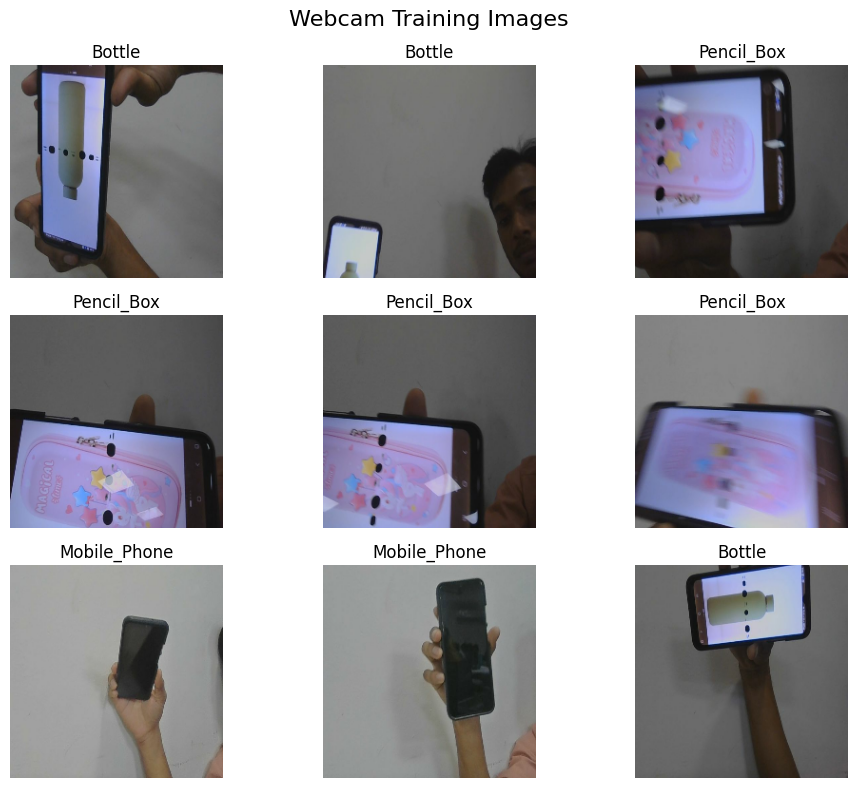

In [15]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.suptitle(
    "Webcam Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

print("\nData augmentation created.")


Data augmentation created.


In [17]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded.


In [18]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel compiled successfully.")


Model compiled successfully.


In [21]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2222 - loss: 1.4667 - val_accuracy: 0.3333 - val_loss: 1.3535
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3333 - loss: 1.3295 - val_accuracy: 0.3333 - val_loss: 1.3027
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 733ms/step - accuracy: 0.3194 - loss: 1.4144 - val_accuracy: 0.3889 - val_loss: 1.2480
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 769ms/step - accuracy: 0.3194 - loss: 1.3572 - val_accuracy: 0.4444 - val_loss: 1.1982
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 873ms/step - accuracy: 0.4722 - loss: 1.2307 - val_accuracy: 0.4444 - val_loss: 1.1504
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 742ms/step - accuracy: 0.3472 - loss: 1.3074 - val_accuracy: 0.4444 - val_loss: 1.0967
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4167 - loss: 1.2345 - val_accuracy: 0.4444 - val_loss: 1.0521
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 729ms/step - accuracy: 0.4306 - loss: 1.2165 - val_accuracy: 0.4444 - val_loss: 1.0083


In [22]:
training_accuracy = history.history["accuracy"][-1]

validation_accuracy = history.history["val_accuracy"][-1]

print("\n")
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(
    f"Training Accuracy : "
    f"{training_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy : "
    f"{validation_accuracy * 100:.2f}%"
)



TRAINING COMPLETED
Training Accuracy : 47.22%
Validation Accuracy : 50.00%


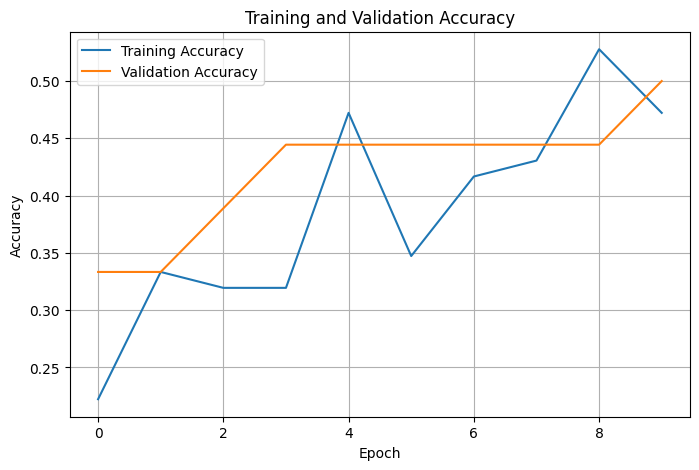

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid()
plt.show()

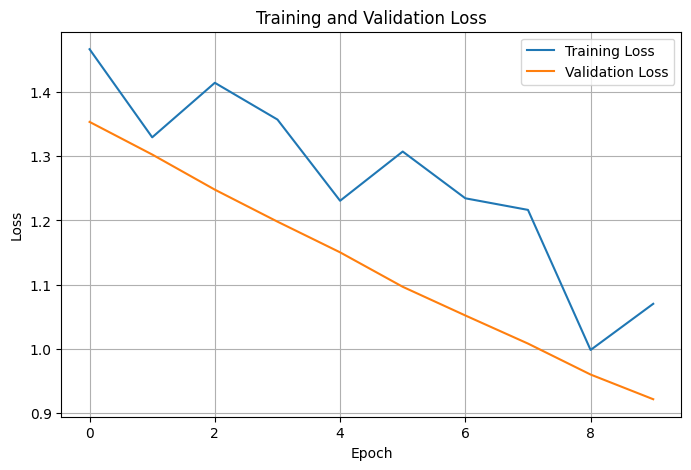

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()
plt.show()

In [25]:
MODEL_PATH = "/content/3D_object_classifier.keras"

model.save(MODEL_PATH)

print("\nModel saved successfully:")
print(MODEL_PATH)

print("\n")
print("=" * 60)
print("TRAINING PIPELINE COMPLETE")
print("=" * 60)


Model saved successfully:
/content/3D_object_classifier.keras


TRAINING PIPELINE COMPLETE


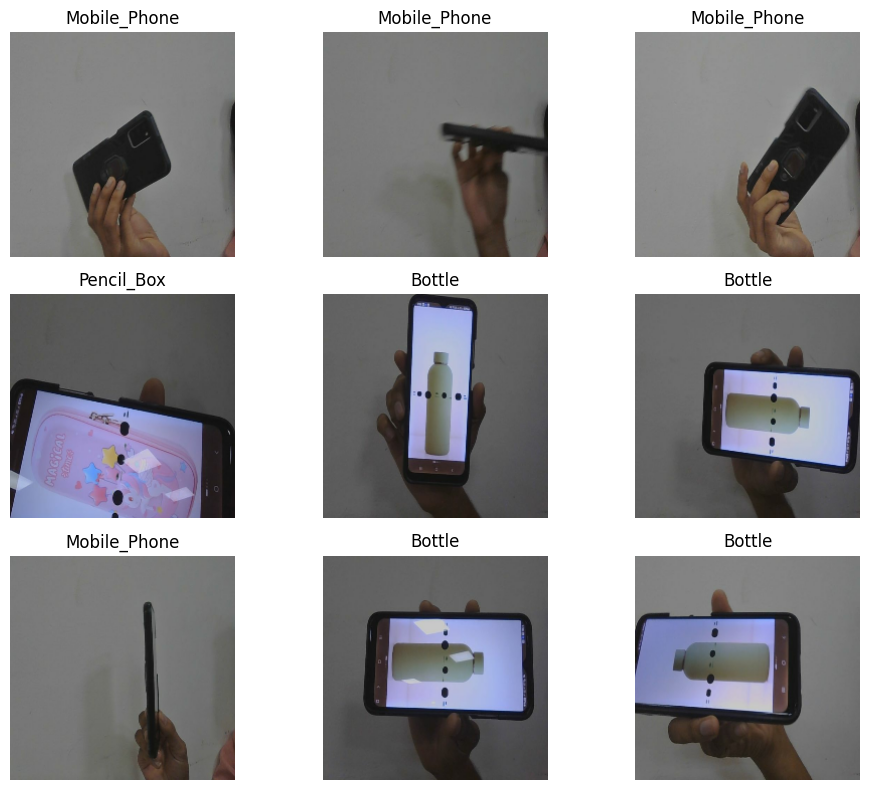

In [26]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()